### José Valbuena - 4.616.729-4

### Data Science II #90420


## 1. Formulación del Problema
Las cancelaciones de reservas generan incertidumbre para los establecimientos hoteleros, ya que pueden afectar la planificación de la ocupación, la disponibilidad de habitaciones y la gestión de ingresos. La posibilidad de identificar anticipadamente aquellas reservas con mayor probabilidad de cancelación puede aportar información útil para la toma de decisiones operativas y comerciales.

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de estimar la probabilidad de que una reserva hotelera sea cancelada, utilizando únicamente información disponible al momento de registrar la reserva.

El problema corresponde a una tarea de clasificación supervisada binaria. Cada observación del dataset representa una reserva y la variable objetivo es is_canceled, donde 0 indica que la reserva no fue cancelada y 1 que fue cancelada.

La pregunta principal del proyecto es: ¿es posible predecir si una reserva hotelera será cancelada a partir de las características conocidas al momento de realizarla?

Como métrica principal para la comparación de modelos se utilizará ROC-AUC, debido a que permite evaluar la capacidad del modelo para discriminar entre reservas canceladas y no canceladas independientemente de un umbral de clasificación específico. Esta evaluación será complementada mediante Precision, Recall, F1-score y matriz de confusión.

En las etapas posteriores también se analizará el umbral de clasificación desde una perspectiva de negocio, considerando las consecuencias de no detectar una futura cancelación frente a clasificar incorrectamente como riesgosa una reserva que finalmente se mantiene.





## 2. Comprensión y auditoría inicial del dataset

### 2.1 Importación de librerías y carga del dataset

In [1]:
# Manejo de rutas y utilidades del entorno
from pathlib import Path
import sys

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Scikit-learn para preparación y validación
import sklearn
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost

# Métricas y visualizaciones de evaluación
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    make_scorer,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Explicabilidad y persistencia del modelo
import shap
import joblib

# Utilidad para mostrar objetos de forma explícita en Jupyter
from IPython.display import display

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Definimos posibles ubicaciones del archivo para que el notebook
# pueda ejecutarse tanto en Google Colab como en un entorno local.
rutas_posibles = [
    Path("/content/hotel_bookings.csv"),
    Path("/content/hotel_bookings(1).csv"),
    Path("hotel_bookings.csv"),
    Path("hotel_bookings(1).csv"),
    Path("/mnt/data/hotel_bookings(1).csv")
]

ruta_dataset = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró hotel_bookings.csv. "
        "Sube el archivo al entorno o actualiza la ruta del dataset."
    )

df = pd.read_csv(ruta_dataset)
print(f"Dataset cargado desde: {ruta_dataset}")

Dataset cargado desde: /content/hotel_bookings.csv


In [3]:
# primeras lineas del dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 2.2 Dimensiones del dataset

In [4]:
# dimensiones del dataset
print(f'Cantidad de filas: {df.shape[0]}')
print(f'Cantidad de columnas: {df.shape[1]}')

Cantidad de filas: 119390
Cantidad de columnas: 32


El dataset contiene 119.390 observaciones y 32 variables. Cada observación corresponde a una reserva hotelera.

### 2.3 Visualización de todas las columnas

In [5]:
# Mostramos los nombres de todas las variables del dataset
for i, columna in enumerate(df.columns, start=1):
    print(f"{i:02d}. {columna}")

01. hotel
02. is_canceled
03. lead_time
04. arrival_date_year
05. arrival_date_month
06. arrival_date_week_number
07. arrival_date_day_of_month
08. stays_in_weekend_nights
09. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date


### 2.4 Información general y tipos de datos

In [6]:
# Informacion general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
# Contamos cúantas columnas existen de cada tipo de dato
df.dtypes.value_counts()

,count
int64,16
object,12
float64,4


In [8]:
# Resumen estadístico descriptivo de las variables del DataFrame
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### 2.5 Tabla de auditoría inicial

In [9]:
# Construimos una tabla resumen para auditar todas las variables
auditoria = pd.DataFrame({

    # Tipo de dato detectado por pandas
    "tipo_dato": df.dtypes,

    # Cantidad de valores diferentes en cada columna
    "valores_unicos": df.nunique(dropna=True),

    # Cantidad total de valores faltantes
    "valores_nulos": df.isna().sum(),

    # Porcentaje de valores faltantes respecto al total de filas
    "porcentaje_nulos": df.isna().mean() * 100
})

auditoria["porcentaje_nulos"] = (
    auditoria["porcentaje_nulos"].round(4)
)

auditoria

,tipo_dato,valores_unicos,valores_nulos,porcentaje_nulos
hotel,object,2,0,0.0000
is_canceled,int64,2,0,0.0000
lead_time,int64,479,0,0.0000
arrival_date_year,int64,3,0,0.0000
arrival_date_month,object,12,0,0.0000
arrival_date_week_number,int64,53,0,0.0000
arrival_date_day_of_month,int64,31,0,0.0000
stays_in_weekend_nights,int64,17,0,0.0000
stays_in_week_nights,int64,35,0,0.0000
adults,int64,14,0,0.0000


### 2.6 Identificación de variables con valores faltantes

In [10]:
# Seleccionamos únicamente las variables que contienen al menos un valor faltante
faltantes = auditoria[auditoria["valores_nulos"] > 0].copy()

# Ordenamos desde la variable con mayor porcentaje de valores faltantes hasta la de menor porcentaje
faltantes = faltantes.sort_values(
    by="porcentaje_nulos",
    ascending=False
)

faltantes

,tipo_dato,valores_unicos,valores_nulos,porcentaje_nulos
company,float64,352,112593,94.3069
agent,float64,333,16340,13.6862
country,object,177,488,0.4087
children,float64,5,4,0.0034


Se identificaron valores faltantes en cuatro variables. company presenta el mayor porcentaje de ausencias, seguido por agent. En cambio, country y children presentan proporciones mucho menores.
En esta etapa no se realiza ninguna imputación ni eliminación, ya que primero será necesario estudiar qué representan estos valores faltantes y determinar una estrategia adecuada en función del significado de cada variable.

### 2.7 Separación inicial entre variables numéricas y categóricas

In [11]:
# Seleccionamos las columnas almacenadas como números
columnas_numericas = df.select_dtypes(
    include=np.number
).columns.tolist()

# Seleccionamos las columnas almacenadas como texto/categorías
columnas_categoricas = df.select_dtypes(
    include="object"
).columns.tolist()

print(f"Variables numéricas: {len(columnas_numericas)}")
print(f"Variables categóricas/object: {len(columnas_categoricas)}")

Variables numéricas: 20
Variables categóricas/object: 12


In [12]:
# Mostramos las variables numéricas
columnas_numericas

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [13]:
# Mostramos las variables almacenadas como object
columnas_categoricas

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

Esta clasificación corresponde únicamente al tipo de dato almacenado en pandas. Algunas variables numéricas, como agent y company, representan identificadores y no magnitudes cuantitativas. Del mismo modo, algunas variables enteras son conceptualmente binarias o categóricas, como is_canceled e is_repeated_guest.

### 2.8 Cardinalidad de las variables

In [14]:
# Calculamos la cantidad de valores únicos de cada variable
cardinalidad = df.nunique(dropna=True)

# Ordenamos desde menor a mayor cardinalidad
cardinalidad = cardinalidad.sort_values()

# Convertimos el resultado en DataFrame para facilitar su lectura
cardinalidad = cardinalidad.to_frame(
    name="cantidad_valores_unicos"
)

cardinalidad

,cantidad_valores_unicos
hotel,2
is_canceled,2
is_repeated_guest,2
arrival_date_year,3
deposit_type,3
reservation_status,3
customer_type,4
babies,5
meal,5
distribution_channel,5


### 2.9 Análisis inicial de la variable objetivo

In [15]:
# Contamos cuántas observaciones existen de cada clase
conteo_target = df["is_canceled"].value_counts().sort_index()

# Calculamos la proporción porcentual de cada clase
porcentaje_target = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Creamos una tabla con cantidad y porcentaje de cada clase
distribucion_target = pd.DataFrame({
    "cantidad": conteo_target,
    "porcentaje": porcentaje_target
})

# Agregamos etiquetas más fáciles de interpretar
distribucion_target.index = [
    "No cancelada (0)",
    "Cancelada (1)"
]

distribucion_target

,cantidad,porcentaje
No cancelada (0),75166,62.96
Cancelada (1),44224,37.04


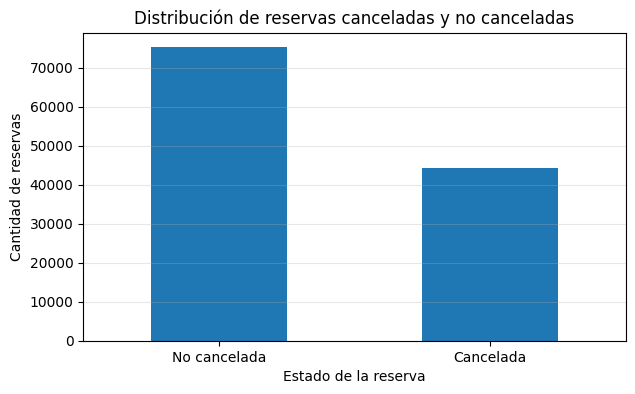

In [16]:
# Creamos un gráfico de barras para visualizar la distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(7, 4))

# Graficamos la cantidad de reservas de cada clase
conteo_target.plot(
    kind="bar",
    ax=ax
)

# Agregamos título y etiquetas
ax.set_title("Distribución de reservas canceladas y no canceladas")
ax.set_xlabel("Estado de la reserva")
ax.set_ylabel("Cantidad de reservas")

# Reemplazamos los valores 0 y 1 por nombres comprensibles
ax.set_xticklabels(
    ["No cancelada", "Cancelada"],
    rotation=0
)

# Agregamos una cuadrícula horizontal suave para facilitar  la comparación visual de las cantidades
ax.grid(axis="y", alpha=0.3)

plt.show()

La clase mayoritaria corresponde a las reservas no canceladas, que representan aproximadamente el 62,96 % del dataset, mientras que las canceladas representan el 37,04 %.
Existe cierto desbalance entre las clases, aunque no es extremo. En esta etapa no se aplicarán técnicas de balanceo; su necesidad será evaluada posteriormente a partir del desempeño de los modelos y de las métricas orientadas a la clase positiva.

### 2.10 Resumen de variables categóricas

In [17]:
# Mostramos solamente las 10 categorías más frecuentes de cada variable categórica para evitar una salida excesiva.
for columna in columnas_categoricas:

    print(f"\n--- {columna} ---")

    print(
        df[columna]
        .value_counts(dropna=False)
        .head(10)
    )


--- hotel ---
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

--- arrival_date_month ---
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
Name: count, dtype: int64

--- meal ---
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

--- country ---
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

--- distribution_channel ---
distribution_channel
TA/TO        97870
Direct

### 2.10.1 Visualización de la distribución de variables categóricas

Además de observar las frecuencias en forma de tabla, resulta útil visualizar las categorías principales. Estos gráficos permiten detectar categorías dominantes, categorías poco frecuentes y posibles problemas de desbalance antes de utilizar las variables en los modelos.

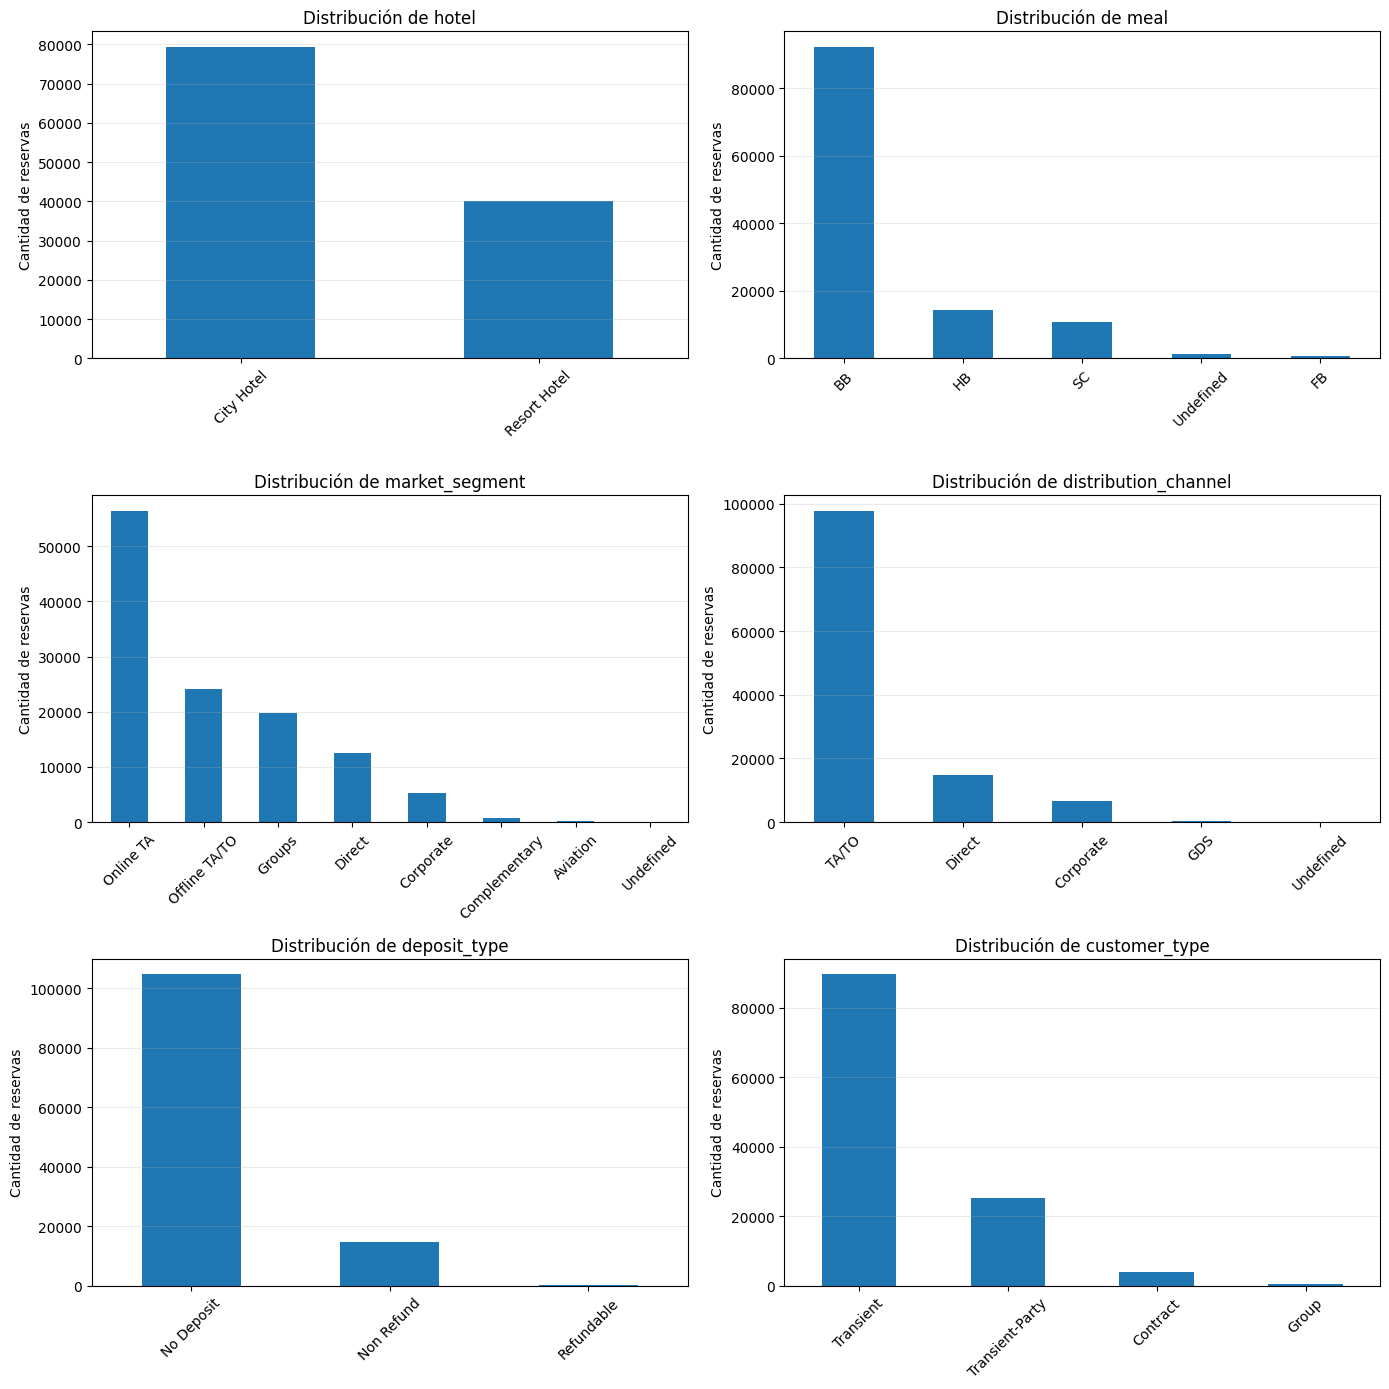

In [18]:
# Seleccionamos variables categóricas de baja o media cardinalidad.
categorias_para_graficar = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, columna in zip(axes, categorias_para_graficar):
    conteos = df[columna].value_counts(dropna=False)
    conteos.plot(kind="bar", ax=ax)

    ax.set_title(f"Distribución de {columna}")
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de reservas")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

En las variables categóricas se observa que algunas categorías concentran gran parte de las reservas. Por ejemplo, `City Hotel` es más frecuente que `Resort Hotel`, `No Deposit` domina en `deposit_type` y `Online TA` es una de las categorías principales de `market_segment`.

Estas diferencias son relevantes porque las categorías muy poco frecuentes pueden aportar poca información estable y requieren un tratamiento cuidadoso durante el encoding.

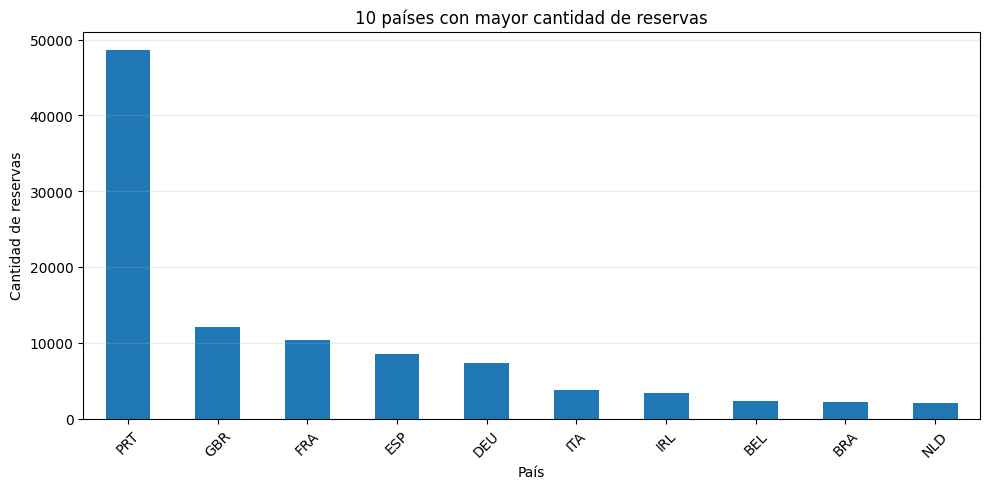

In [19]:
# country tiene alta cardinalidad, por lo que mostramos
# únicamente los 10 países con mayor cantidad de reservas.
top_paises = df["country"].value_counts(dropna=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_paises.plot(kind="bar", ax=ax)

ax.set_title("10 países con mayor cantidad de reservas")
ax.set_xlabel("País")
ax.set_ylabel("Cantidad de reservas")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

`country` presenta una cardinalidad mucho mayor que el resto de las variables categóricas. Por este motivo, durante el modelado se utilizará un encoder capaz de manejar categorías no vistas y categorías poco frecuentes.

### 2.11 Duplicados

In [20]:
# Identificamos filas que son exactamente iguales considerando las 32 variables del dataset.
cantidad_duplicados = df.duplicated().sum()

porcentaje_duplicados = (
    cantidad_duplicados / len(df) * 100
)

print(f"Filas duplicadas exactas: {cantidad_duplicados:,}")
print(f"Porcentaje: {porcentaje_duplicados:.2f}%")

Filas duplicadas exactas: 31,994
Porcentaje: 26.80%


Se detectaron 31.994 registros exactamente duplicados, equivalentes aproximadamente al 26,8 % del dataset. Sin embargo, el conjunto de datos no contiene un identificador único de reserva, por lo que no es posible concluir únicamente a partir de esta comparación que todos estos registros sean duplicados erróneos. Su tratamiento se analizará posteriormente antes de decidir si corresponde eliminarlos.

### 2.12 Detección de valores atipicos

In [21]:
# Calculamos temporalmente el número total de huéspedes. No modificamos todavía el DataFrame original con una nueva columna.
total_huespedes = (
    df["adults"]
    + df["children"].fillna(0)
    + df["babies"]
)

# Calculamos temporalmente el total de noches reservadas.
total_noches = (
    df["stays_in_weekend_nights"]
    + df["stays_in_week_nights"]
)

In [22]:
# Cantidad de reservas sin adultos
print(
    "Reservas con 0 adultos:",
    (df["adults"] == 0).sum()
)

# Cantidad de reservas donde el total de huéspedes es 0
print(
    "Reservas con 0 huéspedes:",
    (total_huespedes == 0).sum()
)

# Cantidad de reservas con 0 noches registradas
print(
    "Reservas con 0 noches:",
    (total_noches == 0).sum()
)

# Valores negativos en ADR
print(
    "Reservas con ADR negativo:",
    (df["adr"] < 0).sum()
)

# Reservas con ADR igual a cero
print(
    "Reservas con ADR igual a 0:",
    (df["adr"] == 0).sum()
)

Reservas con 0 adultos: 403
Reservas con 0 huéspedes: 180
Reservas con 0 noches: 715
Reservas con ADR negativo: 1
Reservas con ADR igual a 0: 1959


### 2.13 Tabla resumen de problemas detectados

In [23]:
# Creamos una tabla resumen con algunas situaciones que requieren investigación posterior.
problemas_iniciales = pd.DataFrame({
    "situacion": [
        "Filas duplicadas exactas",
        "Reservas con 0 adultos",
        "Reservas con 0 huéspedes",
        "Reservas con 0 noches",
        "Reservas con ADR negativo",
        "Reservas con ADR igual a 0"
    ],
    "cantidad": [
        df.duplicated().sum(),
        (df["adults"] == 0).sum(),
        (total_huespedes == 0).sum(),
        (total_noches == 0).sum(),
        (df["adr"] < 0).sum(),
        (df["adr"] == 0).sum()
    ]
})

problemas_iniciales

,situacion,cantidad
0,Filas duplicadas exactas,31994
1,Reservas con 0 adultos,403
2,Reservas con 0 huéspedes,180
3,Reservas con 0 noches,715
4,Reservas con ADR negativo,1
5,Reservas con ADR igual a 0,1959


### 2.14 Identificación de posibles variables problemáticas para ML

In [24]:
# Variables que contienen información que podría estar disponible después del momento en que queremos predecir la cancelación.

# No las eliminamos todavía en esta etapa. Se analizarán formalmente en la sección de Data Leakage.
posibles_variables_leakage = [
    "reservation_status",
    "reservation_status_date"
]

posibles_variables_leakage

['reservation_status', 'reservation_status_date']

Durante la inspección inicial se identificaron reservation_status y reservation_status_date como variables que podrían contener información posterior al resultado de la reserva. Dado que el objetivo consiste en predecir la cancelación con información disponible previamente, estas variables serán estudiadas específicamente en la etapa de análisis de data leakage.

### 2.15 Resumen de la auditoría inicial

In [25]:
# Resumen general de la auditoría inicial
print("RESUMEN DEL DATASET")
print("-" * 40)

print(f"Observaciones: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")
print(f"Duplicados exactos: {df.duplicated().sum():,}")
print(f"Columnas con valores nulos: {df.isna().any().sum()}")

print("\nDISTRIBUCIÓN DEL TARGET")
print("-" * 40)

for clase, porcentaje in porcentaje_target.items():

    etiqueta = (
        "No cancelada"
        if clase == 0
        else "Cancelada"
    )

    print(
        f"{etiqueta}: "
        f"{porcentaje:.2f}%"
    )

RESUMEN DEL DATASET
----------------------------------------
Observaciones: 119,390
Variables: 32
Duplicados exactos: 31,994
Columnas con valores nulos: 4

DISTRIBUCIÓN DEL TARGET
----------------------------------------
No cancelada: 62.96%
Cancelada: 37.04%


### Conclusiones de la auditoría inicial

El dataset contiene 119.390 reservas y 32 variables. La variable objetivo presenta una distribución de aproximadamente 62,96 % de reservas no canceladas y 37,04 % de reservas canceladas, mostrando un desbalance moderado.
Se encontraron valores faltantes en cuatro variables: company, agent, country y children, siendo company la que presenta la mayor proporción de ausencias.
También se detectaron 31.994 filas exactamente iguales, aunque su eliminación no se realizará automáticamente debido a la ausencia de un identificador único que permita confirmar que corresponden a reservas duplicadas.
La inspección estadística inicial permitió detectar observaciones que requieren un análisis posterior, como reservas con cero huéspedes, cero noches y valores extremos o inusuales en variables como adr, lead_time y adults.
Finalmente, se identificaron variables cuyo momento de disponibilidad debe estudiarse antes del modelado, especialmente reservation_status y reservation_status_date, debido al posible riesgo de introducir información futura en el modelo.
En la siguiente etapa se analizarán estos problemas individualmente para definir las estrategias de limpieza y tratamiento más apropiadas.

## 3. Calidad y limpieza de datos

### 3.1 Creación del conjunto de trabajo

In [26]:
# Creamos una copia del dataset original. Todas las modificaciones de limpieza se realizarán sobre df_clean, manteniendo df sin cambios.
df_clean = df.copy()

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones de la copia: {df_clean.shape}")

Dimensiones originales: (119390, 32)
Dimensiones de la copia: (119390, 32)


### 3.2 Tratamiento de valores faltantes

### 3.2.1 Variable children

In [27]:
# Observamos la frecuencia de los valores presentes en children para decidir cómo tratar los pocos valores faltantes.
df_clean["children"].value_counts(dropna=False).sort_index()

,count
children,
0.0,110796
1.0,4861
2.0,3652
3.0,76
10.0,1
NaN,4


#### Justificación visual de la imputación

Antes de imputar los cuatro valores faltantes de `children`, se observa su distribución. La moda resulta apropiada porque `children` es una variable discreta y el valor 0 concentra ampliamente la mayor parte de las observaciones.

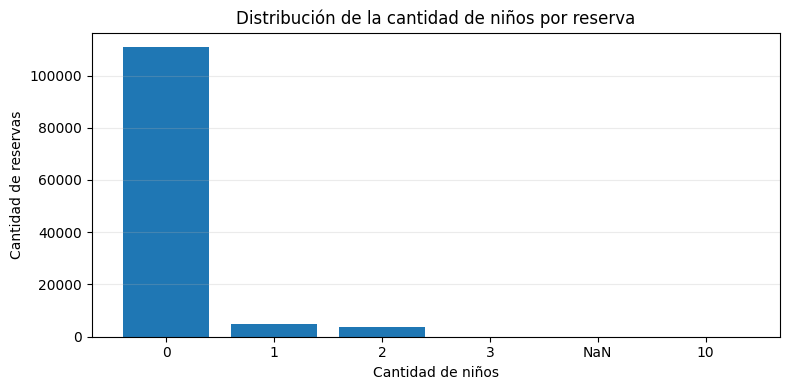

Porcentaje correspondiente a la moda: 92.80%
Porcentaje de valores faltantes: 0.0034%


In [28]:
# Preparamos las frecuencias de children incluyendo valores faltantes.
conteo_children = df_clean["children"].value_counts(dropna=False)

# Convertimos las etiquetas a texto para que NaN aparezca en el gráfico.
etiquetas_children = [
    "NaN" if pd.isna(valor) else str(int(valor))
    for valor in conteo_children.index
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(etiquetas_children, conteo_children.values)

ax.set_title("Distribución de la cantidad de niños por reserva")
ax.set_xlabel("Cantidad de niños")
ax.set_ylabel("Cantidad de reservas")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

porcentaje_moda_children = (
    (df_clean["children"] == df_clean["children"].mode()[0]).mean() * 100
)
porcentaje_nulos_children = (
    df_clean["children"].isna().mean() * 100
)

print(f"Porcentaje correspondiente a la moda: {porcentaje_moda_children:.2f}%")
print(f"Porcentaje de valores faltantes: {porcentaje_nulos_children:.4f}%")

El valor `0` representa aproximadamente el **92,8 %** de las reservas, mientras que los valores faltantes de `children` representan solamente alrededor del **0,0034 %** del dataset. Por este motivo, imputar esos cuatro casos con la **moda** introduce una alteración mínima y mantiene la variable dentro de sus valores observados.

No se utiliza la media porque `children` es un conteo discreto. Una media podría producir valores no interpretables, como 0,1 o 0,2 niños.

In [29]:
# Calculamos la moda de children. La moda representa el valor más frecuente de la variable.
moda_children = df_clean["children"].mode()[0]

print(f"Moda de children: {moda_children}")

Moda de children: 0.0


### 3.2.2 Imputación de `children`

Luego de analizar su distribución, se imputan los cuatro valores faltantes utilizando la moda y se convierte la variable a entero, ya que representa una cantidad de personas.

In [30]:
# Calculamos nuevamente la moda para dejar explícito el valor utilizado.
moda_children = df_clean["children"].mode()[0]

# Imputamos los 4 valores faltantes con la moda.
df_clean["children"] = df_clean["children"].fillna(moda_children)

# Convertimos la variable a entero porque representa una cantidad.
df_clean["children"] = df_clean["children"].astype(int)

print(f"Moda utilizada: {moda_children}")
print("Valores faltantes restantes en children:", df_clean["children"].isna().sum())

Moda utilizada: 0.0
Valores faltantes restantes en children: 0


### 3.2.3 Variable `country`

`country` contiene una proporción pequeña de valores faltantes. En lugar de asignar automáticamente el país más frecuente, se crea la categoría `Unknown`, evitando inventar una nacionalidad que no está observada.

In [31]:
# Reemplazamos los valores faltantes de country por una categoría explícita.
df_clean["country"] = df_clean["country"].fillna("Unknown")
print("Valores faltantes restantes en country:", df_clean["country"].isna().sum())

Valores faltantes restantes en country: 0


### 3.2.4 Variables `agent` y `company`

`agent` y `company` son identificadores, no magnitudes numéricas. Por este motivo no tendría sentido imputarlos con media o mediana. Sus valores faltantes se conservan temporalmente, ya que luego se crearán variables binarias que indiquen si la reserva posee agente o empresa asociada.

In [32]:
# Pandas cargó agent y company como float debido a la presencia de NaN.
# Los convertimos a enteros anulables para reflejar mejor su naturaleza de identificadores.
df_clean["agent"] = df_clean["agent"].astype("Int64")
df_clean["company"] = df_clean["company"].astype("Int64")

# Revisamos los nulos que continúan presentes de forma intencional.
nulos_restantes = df_clean.isna().sum()
nulos_restantes[nulos_restantes > 0]

,0
agent,16340
company,112593


### 3.3 Normalización básica de variables de texto

Se eliminan posibles espacios en blanco al inicio o al final de las categorías. No se modifican mayúsculas y minúsculas porque algunas variables, como los códigos de país, utilizan convenciones específicas.

In [33]:
# Seleccionamos las variables almacenadas como texto.
columnas_texto = df_clean.select_dtypes(include="object").columns

# Quitamos espacios accidentales al inicio y al final.
for columna in columnas_texto:
    df_clean[columna] = df_clean[columna].str.strip()

### 3.4 Reservas sin huéspedes

Una reserva con cero adultos, cero niños y cero bebés no representa una estadía convencional. Se eliminan únicamente estos registros, sin eliminar automáticamente todas las filas donde `adults = 0`, porque algunas de ellas sí contienen niños o bebés.

In [34]:
# Calculamos temporalmente el total de huéspedes por reserva.
total_huespedes = df_clean["adults"] + df_clean["children"] + df_clean["babies"]

# Identificamos las reservas sin huéspedes registrados.
mask_sin_huespedes = total_huespedes == 0

print("Reservas con 0 huéspedes antes de la limpieza:", mask_sin_huespedes.sum())

# Eliminamos únicamente estos casos.
df_clean = df_clean.loc[~mask_sin_huespedes].copy()
print(f"Filas restantes: {len(df_clean):,}")

Reservas con 0 huéspedes antes de la limpieza: 180
Filas restantes: 119,210


### 3.5 Reservas con cero noches

Las reservas con cero noches no se eliminan automáticamente. Pueden representar situaciones válidas del sistema hotelero, como registros administrativos, estadías sin pernocte o reservas que finalmente no generaron noches de alojamiento.

In [35]:
# Calculamos el total de noches reservadas.
total_noches = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
cantidad_cero_noches = (total_noches == 0).sum()
print(f"Reservas con 0 noches: {cantidad_cero_noches}")

Reservas con 0 noches: 645


### 3.6 Tratamiento de valores negativos en `adr`

`adr` representa la tarifa diaria promedio. Se detectó un único valor negativo, difícil de interpretar como una tarifa normal. Debido a que es una sola observación dentro de más de cien mil registros, se elimina.

In [36]:
# Observamos las reservas con ADR negativo.
adr_negativo = df_clean[df_clean["adr"] < 0]

print(f"Registros con ADR negativo: {len(adr_negativo)}")

adr_negativo[[
    "hotel", "adr", "adults",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "is_canceled"
]]

Registros con ADR negativo: 1


,hotel,adr,adults,stays_in_weekend_nights,stays_in_week_nights,is_canceled
14969,Resort Hotel,-6.38,2,4,6,0


In [37]:
# Eliminamos el único registro con ADR negativo.
df_clean = df_clean.loc[df_clean["adr"] >= 0].copy()
print(f"Filas restantes: {len(df_clean):,}")

Filas restantes: 119,209


### 3.7 Reservas con `adr = 0`

A diferencia de un valor negativo, un `adr` igual a cero puede corresponder a promociones, reservas complementarias o situaciones administrativas. Por este motivo estos casos se conservan.

In [38]:
# Contamos las reservas con ADR igual a cero.
cantidad_adr_cero = (df_clean["adr"] == 0).sum()
print(f"Reservas con ADR = 0: {cantidad_adr_cero}")

Reservas con ADR = 0: 1810


### 3.8 Detección de outliers numéricos

Se utiliza el criterio del rango intercuartílico (IQR) como herramienta de detección. Un valor estadísticamente atípico no se elimina automáticamente, ya que puede representar un comportamiento real e informativo para predecir cancelaciones.

In [39]:
# Función auxiliar para detectar valores atípicos utilizando el criterio IQR.
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mask_outliers = (serie < limite_inferior) | (serie > limite_superior)

    return {
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": int(mask_outliers.sum())
    }

variables_outliers = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr"
]

resumen_outliers = []

for columna in variables_outliers:
    resultado = detectar_outliers_iqr(df_clean[columna])

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": resultado["limite_inferior"],
        "limite_superior": resultado["limite_superior"],
        "cantidad_outliers": resultado["cantidad_outliers"]
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.round(2)

,variable,limite_inferior,limite_superior,cantidad_outliers
0,lead_time,-196.50,375.50,2981
1,stays_in_weekend_nights,-3.00,5.00,258
2,stays_in_week_nights,-2.00,6.00,3330
3,adults,2.00,2.00,29530
4,children,0.00,0.00,8590
5,babies,0.00,0.00,917
6,previous_cancellations,0.00,0.00,6479
7,previous_bookings_not_canceled,0.00,0.00,3612
8,booking_changes,0.00,0.00,17977
9,days_in_waiting_list,0.00,0.00,3693


Los outliers detectados se conservan inicialmente. En variables como `lead_time`, `previous_cancellations` o `days_in_waiting_list`, un valor extremo puede representar un comportamiento real y justamente aportar señal predictiva. Su impacto se evaluará durante el EDA y el modelado.

### 3.9 Caso extremo de `adr`

Se revisan los valores máximos de `adr` y algunos percentiles. El objetivo es distinguir entre un valor inusual y un error confirmado.

In [40]:
# Observamos los 10 valores más altos de ADR.
print("Mayores valores de ADR:")
display(df_clean["adr"].nlargest(10).to_frame())

# Analizamos percentiles de la distribución.
percentiles_adr = df_clean["adr"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.00]
)

percentiles_adr

Mayores valores de ADR:


,adr
48515,5400.00
111403,510.00
15083,508.00
103912,451.50
13142,450.00
13391,437.00
39155,426.25
39568,402.00
39118,397.38
13323,392.00


,adr
0.500,94.95000
0.750,126.00000
0.900,164.06000
0.950,193.50000
0.990,252.00000
0.999,326.26136
1.000,5400.00000


El valor máximo de `adr` es extremadamente superior al resto. Sin embargo, no existe evidencia suficiente dentro del dataset para afirmar que sea un error de carga. Se conserva y, para las visualizaciones, se utilizarán límites basados en percentiles cuando sea necesario para evitar que un único punto comprima todo el gráfico.

### 3.10 Análisis de duplicados

Se estudia el impacto de eliminar duplicados antes de tomar una decisión. Debido a que no existe un identificador único de reserva, dos filas idénticas podrían corresponder a reservas diferentes con las mismas características.

In [41]:
# Calculamos la tasa de cancelación conservando los registros repetidos.
tasa_cancelacion_con_duplicados = df_clean["is_canceled"].mean() * 100

# Creamos una versión temporal sin duplicados solo para comparar.
df_sin_duplicados_temporal = df_clean.drop_duplicates()

tasa_cancelacion_sin_duplicados = (
    df_sin_duplicados_temporal["is_canceled"].mean() * 100
)

print(f"Duplicados exactos actuales: {df_clean.duplicated().sum():,}")
print(
    f"Tasa de cancelación conservando duplicados: "
    f"{tasa_cancelacion_con_duplicados:.2f}%"
)
print(
    f"Tasa de cancelación eliminando duplicados: "
    f"{tasa_cancelacion_sin_duplicados:.2f}%"
)

Duplicados exactos actuales: 31,980
Tasa de cancelación conservando duplicados: 37.08%
Tasa de cancelación eliminando duplicados: 27.52%


Eliminar todos los duplicados reduce de forma considerable la proporción de reservas canceladas. Como no existe un `booking_id` que permita demostrar que sean errores de duplicación, se decide **conservarlos**.

Más adelante, para evitar una estimación artificialmente optimista, la separación entre entrenamiento y prueba se realizará agrupando observaciones con las mismas características predictoras, de modo que registros idénticos no aparezcan simultáneamente en ambos conjuntos.

### 3.11 Categorías `Undefined`

Algunas variables categóricas contienen la etiqueta `Undefined`. Se cuantifican, pero no se convierten automáticamente a `NaN`, ya que son categorías explícitas del dataset y pueden representar una codificación propia del sistema.

In [42]:
# Contamos la categoría Undefined en algunas variables categóricas.
for columna in [
    "meal",
    "market_segment",
    "distribution_channel"
]:
    cantidad = df_clean[columna].eq("Undefined").sum()
    print(f"{columna}: {cantidad} valores Undefined")

meal: 1169 valores Undefined
market_segment: 2 valores Undefined
distribution_channel: 5 valores Undefined


### 3.12 Comprobación final de la limpieza básica

In [43]:
# Recalculamos el total de huéspedes después de la limpieza.
total_huespedes_clean = (
    df_clean["adults"]
    + df_clean["children"]
    + df_clean["babies"]
)

print("Reservas sin huéspedes:", (total_huespedes_clean == 0).sum())
print("ADR negativos:", (df_clean["adr"] < 0).sum())
print("Nulos en children:", df_clean["children"].isna().sum())
print("Nulos en country:", df_clean["country"].isna().sum())

Reservas sin huéspedes: 0
ADR negativos: 0
Nulos en children: 0
Nulos en country: 0


In [44]:
# Comparamos el tamaño antes y después de la limpieza básica.
comparacion_limpieza = pd.DataFrame({
    "Dataset": ["Original", "Después de limpieza"],
    "Filas": [len(df), len(df_clean)],
    "Columnas": [df.shape[1], df_clean.shape[1]]
})

comparacion_limpieza

,Dataset,Filas,Columnas
0,Original,119390,32
1,Después de limpieza,119209,32


### Conclusiones de la limpieza

La limpieza aplicada fue conservadora. Se imputaron los pocos valores faltantes de `children`, se creó una categoría explícita para los países desconocidos y se conservaron temporalmente los identificadores `agent` y `company`.

Se eliminaron únicamente las reservas sin huéspedes y el único registro con `adr` negativo. Las reservas con cero noches, `adr = 0`, outliers y registros repetidos se conservaron porque pueden representar situaciones reales y no existe evidencia suficiente para considerarlos errores.

Luego de esta etapa, el dataset pasa de **119.390 a 119.209 observaciones**.

## 4. Análisis de Data Leakage

El objetivo del proyecto es predecir una cancelación utilizando información disponible al momento de registrar la reserva. Por lo tanto, cualquier variable que se genere después de ese momento puede entregar al modelo información del futuro y producir resultados artificialmente altos.

### 4.1 Evaluación del momento de disponibilidad de las variables

In [45]:
# Construimos una tabla explícita con las variables que requieren una decisión
# especial por su momento de disponibilidad o por ser identificadores.
decision_variables = pd.DataFrame({
    "variable": [
        "reservation_status",
        "reservation_status_date",
        "assigned_room_type",
        "booking_changes",
        "days_in_waiting_list",
        "agent",
        "company"
    ],
    "decision": [
        "Excluir",
        "Excluir",
        "Excluir",
        "Excluir",
        "Excluir",
        "Transformar",
        "Transformar"
    ],
    "motivo": [
        "Describe el resultado final de la reserva.",
        "Fecha asociada al estado final de la reserva.",
        "La habitación asignada puede conocerse después de la reserva.",
        "Resume cambios realizados después del registro inicial.",
        "Puede acumularse después de crear la reserva.",
        "Es un identificador de alta cardinalidad; se utilizará su presencia.",
        "Es un identificador de alta cardinalidad; se utilizará su presencia."
    ]
})

decision_variables

,variable,decision,motivo
0,reservation_status,Excluir,Describe el resultado final de la reserva.
1,reservation_status_date,Excluir,Fecha asociada al estado final de la reserva.
2,assigned_room_type,Excluir,La habitación asignada puede conocerse después...
3,booking_changes,Excluir,Resume cambios realizados después del registro...
4,days_in_waiting_list,Excluir,Puede acumularse después de crear la reserva.
5,agent,Transformar,Es un identificador de alta cardinalidad; se u...
6,company,Transformar,Es un identificador de alta cardinalidad; se u...


`reservation_status` y `reservation_status_date` constituyen leakage directo porque describen el resultado final. Además, se adopta un criterio conservador con `assigned_room_type`, `booking_changes` y `days_in_waiting_list`, ya que no puede garantizarse que estén disponibles exactamente al momento inicial de la reserva.

`agent` y `company` no se utilizarán como números. En la ingeniería de atributos se transformarán en indicadores binarios de presencia.

## 5. Análisis Exploratorio de Datos (EDA)

Una vez realizada la limpieza básica y definido qué variables no deben utilizarse como predictoras, se estudian distribuciones y relaciones con `is_canceled`. El objetivo es obtener insights y orientar la ingeniería de atributos.

### 5.1 Distribuciones de variables numéricas principales

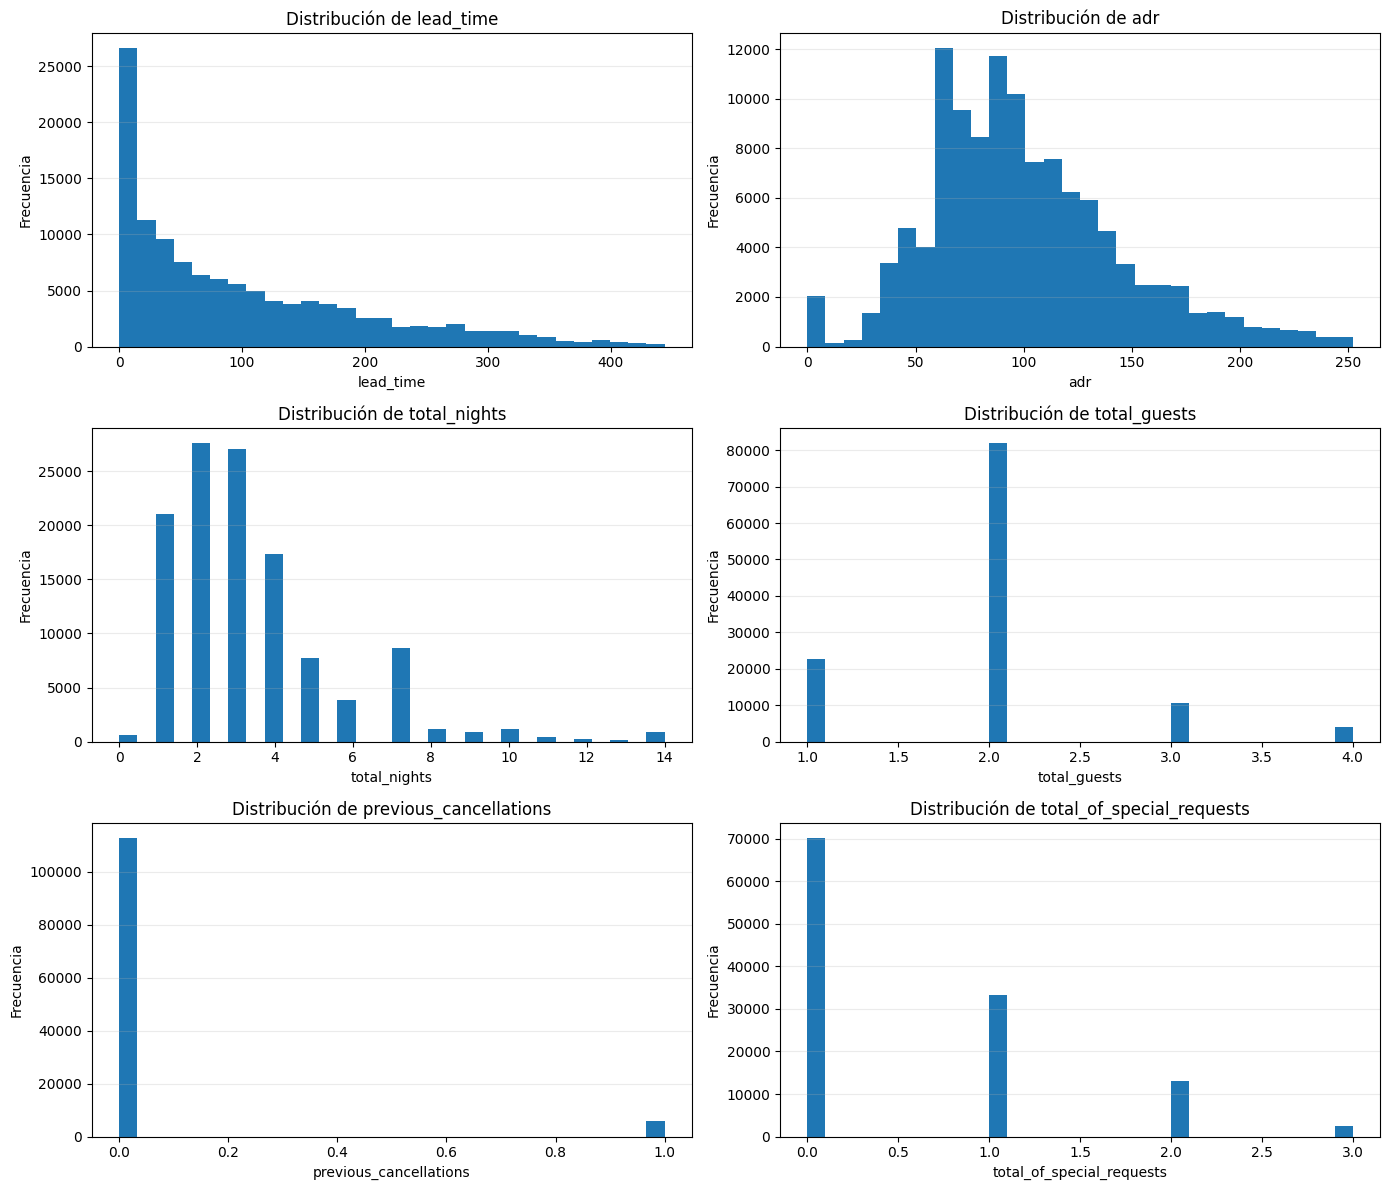

In [46]:
# Creamos variables auxiliares únicamente para el análisis exploratorio.
df_eda = df_clean.copy()

df_eda["total_nights"] = (
    df_eda["stays_in_weekend_nights"]
    + df_eda["stays_in_week_nights"]
)

df_eda["total_guests"] = (
    df_eda["adults"]
    + df_eda["children"]
    + df_eda["babies"]
)

variables_numericas_eda = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "previous_cancellations",
    "total_of_special_requests"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, columna in zip(axes, variables_numericas_eda):
    # Limitamos la visualización al percentil 99 para evitar
    # que pocos valores extremos compriman todo el histograma.
    limite_visual = df_eda[columna].quantile(0.99)
    datos_visual = df_eda.loc[df_eda[columna] <= limite_visual, columna]

    ax.hist(datos_visual, bins=30)
    ax.set_title(f"Distribución de {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### 5.2 Tasa de cancelación por variables categóricas

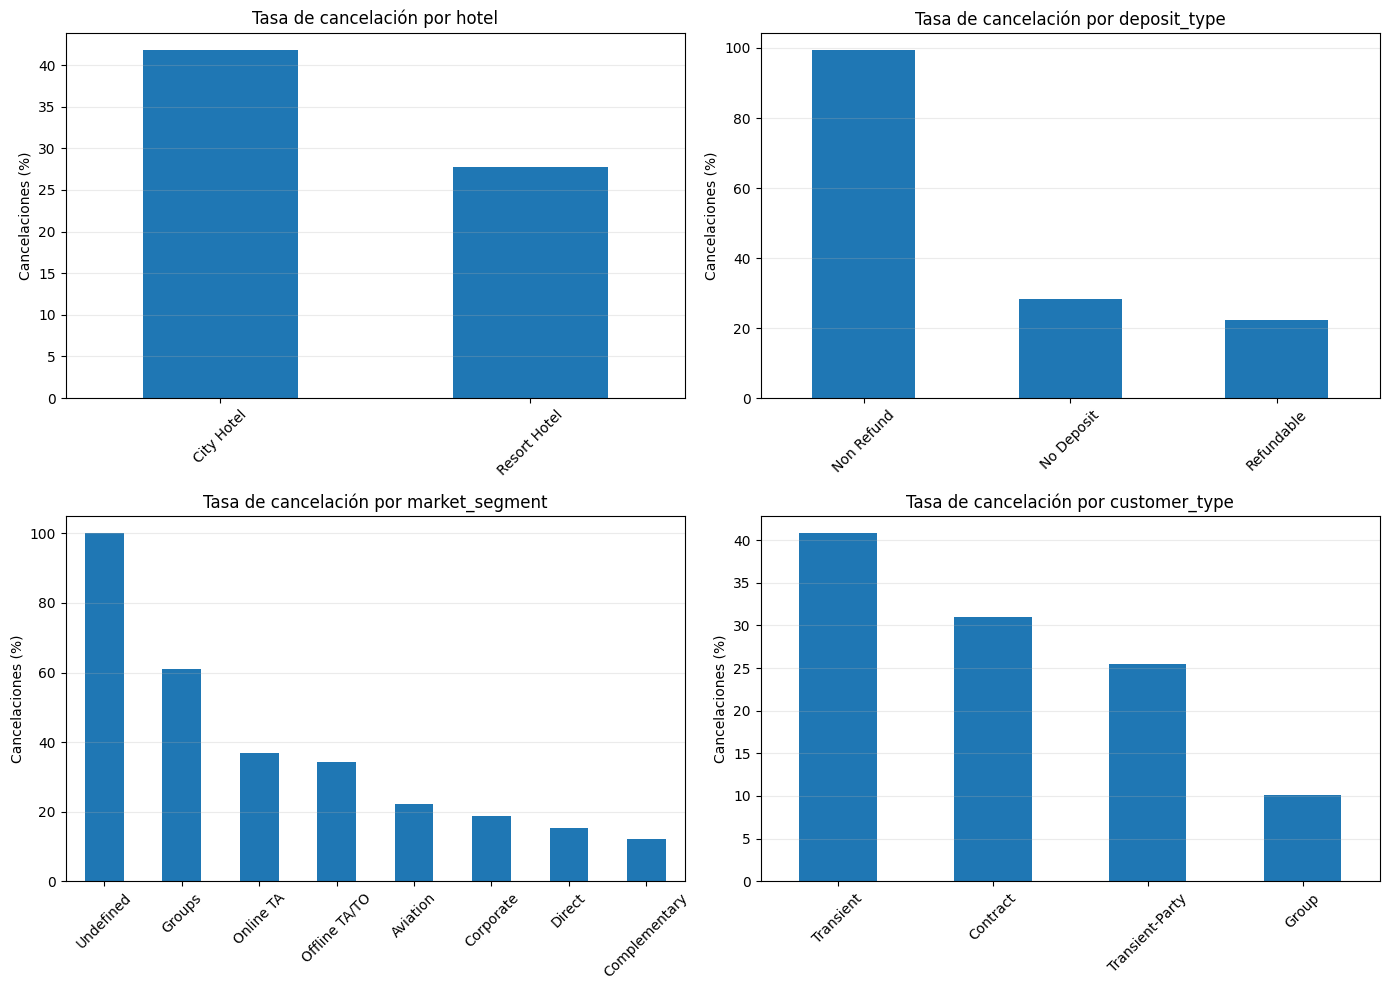

In [47]:
categorias_vs_target = [
    "hotel",
    "deposit_type",
    "market_segment",
    "customer_type"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, columna in zip(axes, categorias_vs_target):
    tasa = (
        df_eda.groupby(columna)["is_canceled"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    tasa.plot(kind="bar", ax=ax)

    ax.set_title(f"Tasa de cancelación por {columna}")
    ax.set_xlabel("")
    ax.set_ylabel("Cancelaciones (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Los gráficos muestran diferencias claras entre categorías. `City Hotel` presenta una tasa de cancelación superior a `Resort Hotel`. También destaca `Non Refund` dentro de `deposit_type`, cuya tasa de cancelación es muy elevada en este dataset. Estos patrones justifican conservar estas variables como candidatas predictoras.

### 5.3 Países con mayor volumen de reservas y su tasa de cancelación

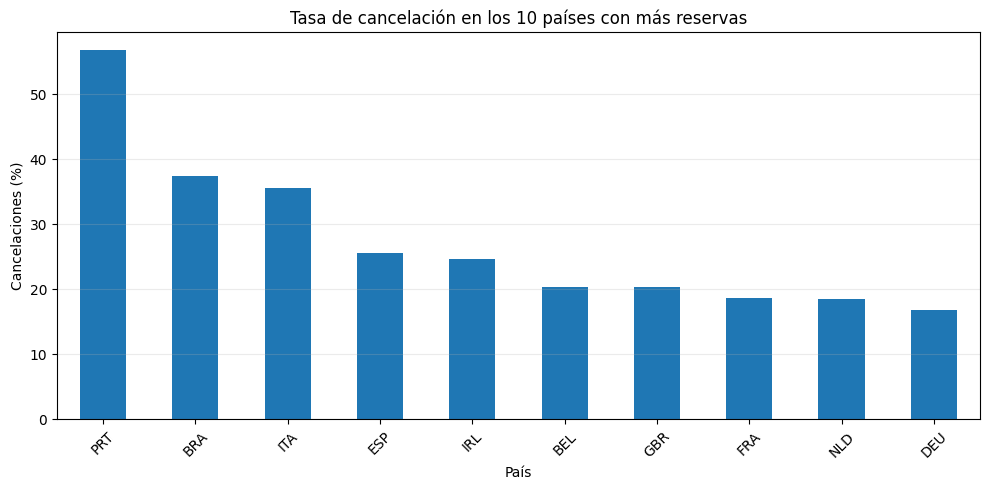

,mean,count,cancelacion_pct
country,,,
PRT,0.57,48483,56.73
BRA,0.37,2222,37.35
ITA,0.35,3761,35.44
ESP,0.25,8560,25.43
IRL,0.25,3374,24.66
BEL,0.20,2342,20.24
GBR,0.20,12119,20.23
FRA,0.19,10401,18.58
NLD,0.18,2103,18.40


In [48]:
# Seleccionamos los 10 países con más observaciones.
top_10_paises = df_eda["country"].value_counts().head(10).index

tasa_paises = (
    df_eda[df_eda["country"].isin(top_10_paises)]
    .groupby("country")["is_canceled"]
    .agg(["mean", "count"])
)

tasa_paises["cancelacion_pct"] = tasa_paises["mean"] * 100
tasa_paises = tasa_paises.sort_values("cancelacion_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
tasa_paises["cancelacion_pct"].plot(kind="bar", ax=ax)

ax.set_title("Tasa de cancelación en los 10 países con más reservas")
ax.set_xlabel("País")
ax.set_ylabel("Cancelaciones (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

tasa_paises.round(2)

### 5.4 Variables numéricas según cancelación

In [49]:
# Comparamos medias y medianas según el resultado de la reserva.
comparacion_target = (
    df_eda.groupby("is_canceled")[
        [
            "lead_time",
            "adr",
            "total_nights",
            "total_guests",
            "previous_cancellations",
            "total_of_special_requests"
        ]
    ]
    .agg(["mean", "median"])
)

comparacion_target.round(2)

lead_time            adr        total_nights        total_guests  \
                 mean median    mean median         mean median         mean   
is_canceled                                                                    
0               80.08   45.0  100.17   92.7         3.39    3.0         1.95   
1              144.89  113.0  105.02   96.3         3.49    3.0         2.01   

                   previous_cancellations        total_of_special_requests  \
            median                   mean median                      mean   
is_canceled                                                                  
0              2.0                   0.02    0.0                      0.71   
1              2.0                   0.21    0.0                      0.33   

                    
            median  
is_canceled         
0              1.0  
1              0.0

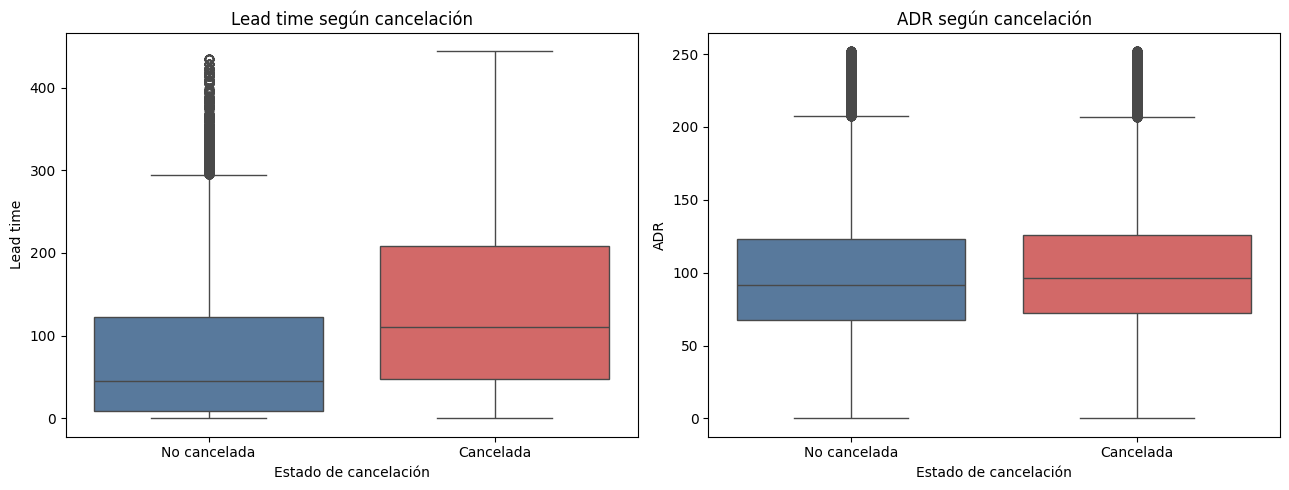

In [82]:
# Boxplots de dos variables relevantes.
paleta_cancelacion = {
    0: "#4C78A8",
    1: "#E45756"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Limitamos la visualización al percentil 99 para que los valores
# extremadamente altos no oculten la forma principal de la distribución.
# Los registros NO se eliminan del dataset; el recorte es solo visual.
lead_limit = df_eda["lead_time"].quantile(0.99)
adr_limit = df_eda["adr"].quantile(0.99)

sns.boxplot(
    data=df_eda[df_eda["lead_time"] <= lead_limit],
    x="is_canceled",
    y="lead_time",
    hue="is_canceled",
    palette=paleta_cancelacion,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Lead time según cancelación")
axes[0].set_xlabel("Estado de cancelación")
axes[0].set_ylabel("Lead time")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No cancelada", "Cancelada"])

sns.boxplot(
    data=df_eda[df_eda["adr"] <= adr_limit],
    x="is_canceled",
    y="adr",
    hue="is_canceled",
    palette=paleta_cancelacion,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("ADR según cancelación")
axes[1].set_xlabel("Estado de cancelación")
axes[1].set_ylabel("ADR")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No cancelada", "Cancelada"])

plt.tight_layout()
plt.show()

Las reservas canceladas presentan un `lead_time` claramente mayor en promedio y mediana. Esto sugiere que reservar con mucha anticipación está asociado con una mayor incertidumbre y puede ser una señal útil para el modelo.

También se observa que las reservas no canceladas tienden a realizar más solicitudes especiales, mientras que el historial de cancelaciones previas es mayor entre las reservas que finalmente se cancelan.

### 5.5 Correlaciones numéricas con la variable objetivo

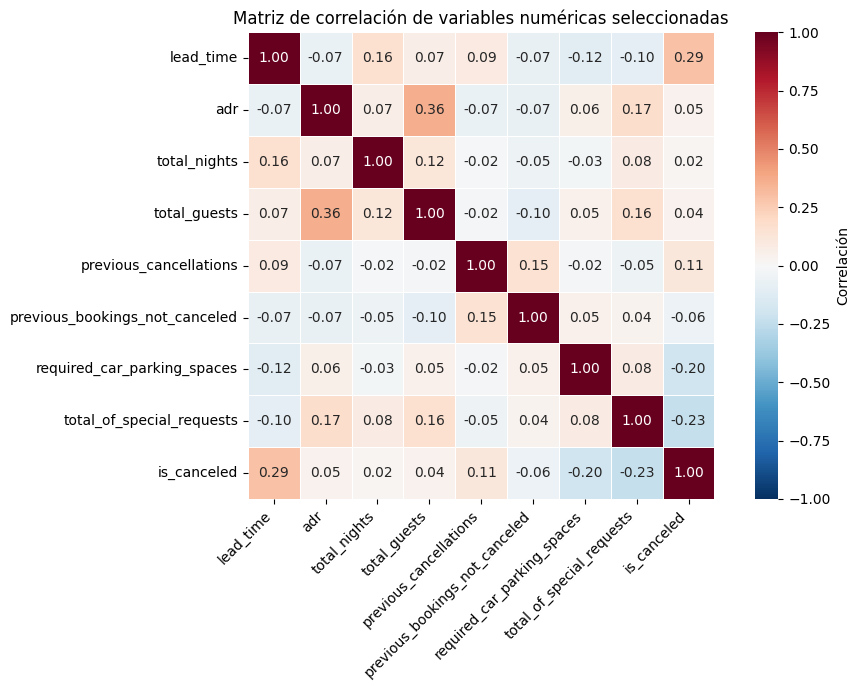

In [83]:
variables_correlacion = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "is_canceled"
]

matriz_correlacion = df_eda[variables_correlacion].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación"},
    ax=ax
)

ax.set_title("Matriz de correlación de variables numéricas seleccionadas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
# Correlación lineal de cada variable seleccionada con is_canceled.
correlacion_target = (
    matriz_correlacion["is_canceled"]
    .drop("is_canceled")
    .sort_values()
)

correlacion_target

,is_canceled
total_of_special_requests,-0.234883
required_car_parking_spaces,-0.195704
previous_bookings_not_canceled,-0.057358
total_nights,0.018571
total_guests,0.044827
adr,0.046479
previous_cancellations,0.110139
lead_time,0.292883


### Principales hallazgos del EDA

- `lead_time` muestra una asociación positiva relevante con la cancelación.
- `total_of_special_requests` y `required_car_parking_spaces` presentan asociación negativa con la cancelación.
- `previous_cancellations` aporta información sobre el comportamiento histórico del cliente.
- Existen diferencias importantes entre categorías de `hotel`, `deposit_type`, `market_segment` y `customer_type`.
- Las relaciones no son exclusivamente lineales, por lo que resulta razonable comparar modelos lineales con árboles y métodos de ensamble.

## 6. Ingeniería de atributos

A partir de los hallazgos del EDA se crean variables que resumen información ya existente y pueden facilitar el aprendizaje de patrones por parte de los modelos.

In [53]:
# Creamos un DataFrame específico para el modelado.
df_model = df_clean.copy()

# Duración total de la estadía.
df_model["total_nights"] = (
    df_model["stays_in_weekend_nights"]
    + df_model["stays_in_week_nights"]
)

# Cantidad total de huéspedes.
df_model["total_guests"] = (
    df_model["adults"]
    + df_model["children"]
    + df_model["babies"]
)

# Indicador de presencia de niños o bebés.
df_model["has_children"] = (
    (df_model["children"] + df_model["babies"]) > 0
).astype(int)

# Indicador simple de reserva familiar.
df_model["is_family"] = (
    (df_model["adults"] > 0)
    & ((df_model["children"] + df_model["babies"]) > 0)
).astype(int)

# Presencia de agente o empresa, evitando usar los IDs como magnitudes.
df_model["has_agent"] = df_model["agent"].notna().astype(int)
df_model["has_company"] = df_model["company"].notna().astype(int)

# Historial total de reservas anteriores.
df_model["total_previous_bookings"] = (
    df_model["previous_cancellations"]
    + df_model["previous_bookings_not_canceled"]
)

# Proporción histórica de cancelaciones.
df_model["previous_cancel_rate"] = np.where(
    df_model["total_previous_bookings"] > 0,
    (
        df_model["previous_cancellations"]
        / df_model["total_previous_bookings"]
    ),
    0.0
)

# Convertimos el mes a número para poder derivar el trimestre.
mapa_meses = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

df_model["arrival_month_num"] = (
    df_model["arrival_date_month"].map(mapa_meses)
)

df_model["arrival_quarter"] = (
    ((df_model["arrival_month_num"] - 1) // 3) + 1
).astype(int)

# Agrupamos lead_time en intervalos interpretables.
df_model["lead_time_group"] = pd.cut(
    df_model["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=[
        "0-7",
        "8-30",
        "31-90",
        "91-180",
        "181-365",
        ">365"
    ]
)

# Tarifa aproximada por huésped.
df_model["adr_per_guest"] = (
    df_model["adr"]
    / df_model["total_guests"].replace(0, np.nan)
)

df_model[
    [
        "total_nights",
        "total_guests",
        "has_children",
        "is_family",
        "has_agent",
        "has_company",
        "total_previous_bookings",
        "previous_cancel_rate",
        "arrival_quarter",
        "lead_time_group",
        "adr_per_guest"
    ]
].head()

,total_nights,total_guests,has_children,is_family,has_agent,has_company,total_previous_bookings,previous_cancel_rate,arrival_quarter,lead_time_group,adr_per_guest
0,0,2,0,0,0,0,0,0.0,3,181-365,0.0
1,0,2,0,0,0,0,0,0.0,3,>365,0.0
2,1,1,0,0,0,0,0,0.0,3,0-7,75.0
3,1,1,0,0,1,0,0,0.0,3,8-30,75.0
4,2,2,0,0,1,0,0,0.0,3,8-30,49.0


### 6.1 Definición final de variables predictoras

Se eliminan del conjunto de entrada las variables identificadas como leakage y los identificadores originales `agent` y `company`, ya que ya fueron resumidos mediante `has_agent` y `has_company`.

In [54]:
# Variables excluidas por riesgo de leakage.
columnas_leakage = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list"
]

# Identificadores originales que no utilizaremos como cantidades.
columnas_id = [
    "agent",
    "company"
]

# Definimos X e y.
X = df_model.drop(
    columns=[
        "is_canceled",
        *columnas_leakage,
        *columnas_id
    ]
)

y = df_model["is_canceled"].astype(int)

print(f"Variables predictoras finales: {X.shape[1]}")
print(f"Observaciones disponibles: {X.shape[0]:,}")

Variables predictoras finales: 36
Observaciones disponibles: 119,209


## 7. Preparación para Machine Learning

El conjunto de prueba debe permanecer aislado hasta la evaluación final. Además, debido a la presencia de registros con características idénticas, se utiliza una separación por grupos para evitar que la misma combinación de predictores aparezca simultáneamente en entrenamiento y prueba.

In [56]:
# Creamos un identificador de grupo a partir de las variables predictoras.
# Filas con exactamente los mismos predictores reciben el mismo hash.
grupos = pd.util.hash_pandas_object(
    X.astype(str),
    index=False
).astype("uint64")

# Reservamos aproximadamente 20% de grupos para el conjunto de prueba.
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(
        X,
        y,
        groups=grupos
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

grupos_train = grupos.iloc[train_idx].copy()
grupos_test = grupos.iloc[test_idx].copy()

print(f"Train: {len(X_train):,} observaciones")
print(f"Test: {len(X_test):,} observaciones")
print(f"Cancelación en train: {y_train.mean() * 100:.2f}%")
print(f"Cancelación en test: {y_test.mean() * 100:.2f}%")

Train: 95,735 observaciones
Test: 23,474 observaciones
Cancelación en train: 37.42%
Cancelación en test: 35.69%


In [57]:
# Verificamos que ningún grupo aparezca en ambos conjuntos.
grupos_compartidos = len(
    set(grupos_train).intersection(set(grupos_test))
)

print(
    "Cantidad de grupos compartidos entre train y test:",
    grupos_compartidos
)

Cantidad de grupos compartidos entre train y test: 0


### 7.1 Pipeline de preprocesamiento

Las variables numéricas se imputan con mediana si apareciera algún faltante futuro y se estandarizan. Las variables categóricas se imputan con la categoría más frecuente y se transforman mediante One-Hot Encoding. `min_frequency=50` agrupa automáticamente categorías muy poco frecuentes.

In [58]:
# Identificamos las variables por tipo utilizando únicamente train.
variables_numericas_modelo = (
    X_train.select_dtypes(include=np.number)
    .columns
    .tolist()
)

variables_categoricas_modelo = (
    X_train.select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print(f"Variables numéricas: {len(variables_numericas_modelo)}")
print(f"Variables categóricas: {len(variables_categoricas_modelo)}")

Variables numéricas: 26
Variables categóricas: 10


In [59]:
# Pipeline para variables numéricas.
transformador_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Pipeline para variables categóricas.
transformador_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=50
            )
        )
    ]
)

# Combinamos ambos tratamientos.
preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, variables_numericas_modelo),
        ("cat", transformador_categorico, variables_categoricas_modelo)
    ]
)

preprocesador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous...
                                  'previous_cancel_rate', 'arrival_month_num',
                                  'arrival_quarter', 'adr_per_guest']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=50))]),
                                 ['hotel', 'arrival_date_month', 'meal',
                                  'country', 'market_segment',
                                  'distribution_channel', 'reserved_room_type',
                                  'deposit_type', 'customer_type',
                                  'lead_time_group'])])

## 8. Modelo baseline

Antes de entrenar modelos complejos se establece una referencia mínima mediante `DummyClassifier`. Este modelo no aprende patrones entre las variables y el target, por lo que sirve para verificar que los modelos reales aporten valor predictivo.

In [61]:
# XGBoost y SHAP fueron importados al inicio del notebook.
# Las dependencias necesarias también se encuentran documentadas
# en requirements.txt para garantizar la reproducibilidad.

### 8.1 Estrategia de validación

La comparación inicial se realiza mediante validación cruzada estratificada por grupos. Así se preserva aproximadamente la proporción de clases y, al mismo tiempo, las observaciones idénticas permanecen dentro del mismo fold.

In [62]:
# Validación cruzada de 3 folds.
cv_grupos = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Métricas para la comparación.
metricas_cv = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    )
}

## 9. Entrenamiento y comparación de modelos

Se comparan modelos de distinta naturaleza: un baseline, un modelo lineal, un árbol individual, un ensamble por bagging y un modelo de boosting.

In [63]:
# Definimos los modelos con configuraciones iniciales razonables.
modelos = {
    "Dummy": DummyClassifier(
        strategy="prior"
    ),

    "Regresión logística": LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ),

    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    )
}

In [64]:
# Guardamos los resultados medios de validación cruzada.
resultados_modelos = []

for nombre, modelo in modelos.items():

    # Cada modelo se integra con el mismo preprocesamiento.
    pipeline_modelo = Pipeline(
        steps=[
            ("preprocesador", preprocesador),
            ("modelo", modelo)
        ]
    )

    resultados_cv = cross_validate(
        pipeline_modelo,
        X_train,
        y_train,
        groups=grupos_train,
        cv=cv_grupos,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_modelos.append({
        "Modelo": nombre,
        "ROC-AUC": resultados_cv["test_roc_auc"].mean(),
        "PR-AUC": resultados_cv["test_pr_auc"].mean(),
        "Precision": resultados_cv["test_precision"].mean(),
        "Recall": resultados_cv["test_recall"].mean(),
        "F1": resultados_cv["test_f1"].mean()
    })

resultados_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

resultados_modelos.round(4)

,Modelo,ROC-AUC,PR-AUC,Precision,Recall,F1
0,XGBoost,0.9263,0.8968,0.8299,0.7399,0.7823
1,Random Forest,0.9257,0.8984,0.8677,0.6903,0.7688
2,Árbol de decisión,0.9113,0.8677,0.8015,0.7458,0.7726
3,Regresión logística,0.8993,0.8666,0.8151,0.6688,0.7347
4,Dummy,0.5000,0.3742,0.0000,0.0000,0.0000


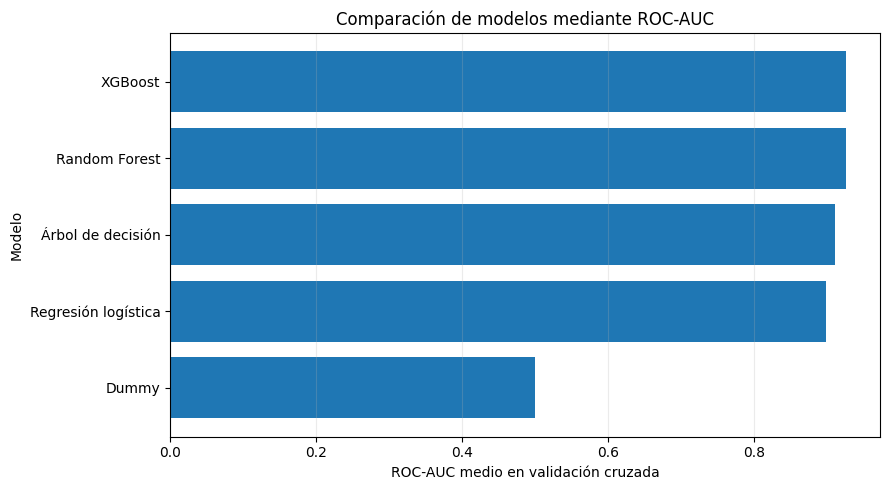

In [65]:
# Visualizamos el ROC-AUC medio de cada modelo.
fig, ax = plt.subplots(figsize=(9, 5))

orden_modelos = resultados_modelos.sort_values("ROC-AUC")

ax.barh(
    orden_modelos["Modelo"],
    orden_modelos["ROC-AUC"]
)

ax.set_title("Comparación de modelos mediante ROC-AUC")
ax.set_xlabel("ROC-AUC medio en validación cruzada")
ax.set_ylabel("Modelo")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

La comparación permite verificar cuánto mejora cada algoritmo respecto al baseline. La selección para optimización se realiza principalmente por ROC-AUC, pero también se observan PR-AUC, Precision, Recall y F1 para evitar elegir un modelo únicamente por una métrica.

## 10. Evaluación inicial y selección del candidato

En esta etapa se identifica el modelo más prometedor antes de optimizar hiperparámetros. El conjunto de prueba todavía no se utiliza.

In [66]:
# Identificamos el modelo con mayor ROC-AUC medio.
mejor_inicial = resultados_modelos.iloc[0]

print("Mejor modelo inicial:")
display(mejor_inicial.to_frame().T)

Mejor modelo inicial:


,Modelo,ROC-AUC,PR-AUC,Precision,Recall,F1
0,XGBoost,0.926344,0.896764,0.829945,0.739932,0.78233


XGBoost se utiliza como candidato para la optimización porque combina un ROC-AUC elevado con buen desempeño en F1 y Recall. Además, es adecuado para relaciones no lineales e interacciones entre características.

## 11. Optimización de hiperparámetros

Se utiliza `RandomizedSearchCV` para explorar distintas configuraciones de XGBoost sin evaluar todas las combinaciones posibles. La optimización se realiza exclusivamente sobre el conjunto de entrenamiento y mantiene la validación por grupos.

In [67]:
# Pipeline específico para XGBoost.
pipeline_xgb = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            XGBClassifier(
                eval_metric="logloss",
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

# Espacio de hiperparámetros.
parametros_xgb = {
    "modelo__n_estimators": [200, 300, 400],
    "modelo__max_depth": [3, 4, 5, 6],
    "modelo__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "modelo__subsample": [0.8, 1.0],
    "modelo__colsample_bytree": [0.8, 1.0]
}

busqueda_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=parametros_xgb,
    n_iter=6,
    scoring="roc_auc",
    cv=cv_grupos,
    random_state=42,
    n_jobs=-1,
    refit=True
)

busqueda_xgb.fit(
    X_train,
    y_train,
    groups=grupos_train
)

print(f"Mejor ROC-AUC CV: {busqueda_xgb.best_score_:.4f}")
print("Mejores hiperparámetros:")
busqueda_xgb.best_params_

Mejor ROC-AUC CV: 0.9307
Mejores hiperparámetros:


{'modelo__subsample': 1.0,
 'modelo__n_estimators': 400,
 'modelo__max_depth': 6,
 'modelo__learning_rate': 0.05,
 'modelo__colsample_bytree': 1.0}

## 12. Selección del modelo y análisis del umbral

El mejor estimador de la búsqueda se adopta como modelo final. Antes de abrir el conjunto de prueba, se estudia el efecto del umbral de clasificación utilizando predicciones out-of-fold del conjunto de entrenamiento.

In [68]:
# Recuperamos el mejor pipeline encontrado.
mejor_modelo = busqueda_xgb.best_estimator_

# Generamos probabilidades out-of-fold sobre train.
probabilidades_oof = cross_val_predict(
    mejor_modelo,
    X_train,
    y_train,
    groups=grupos_train,
    cv=cv_grupos,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Comparamos diferentes umbrales.
resultados_umbral = []

for umbral in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_oof = (probabilidades_oof >= umbral).astype(int)

    resultados_umbral.append({
        "Umbral": umbral,
        "Precision": precision_score(
            y_train,
            pred_oof,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            pred_oof,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            pred_oof,
            zero_division=0
        )
    })

tabla_umbrales = pd.DataFrame(resultados_umbral)
tabla_umbrales.round(4)

,Umbral,Precision,Recall,F1
0,0.3,0.7136,0.8857,0.7904
1,0.4,0.7794,0.8191,0.7988
2,0.5,0.8325,0.7563,0.7925
3,0.6,0.8810,0.6730,0.7631
4,0.7,0.9389,0.5629,0.7038


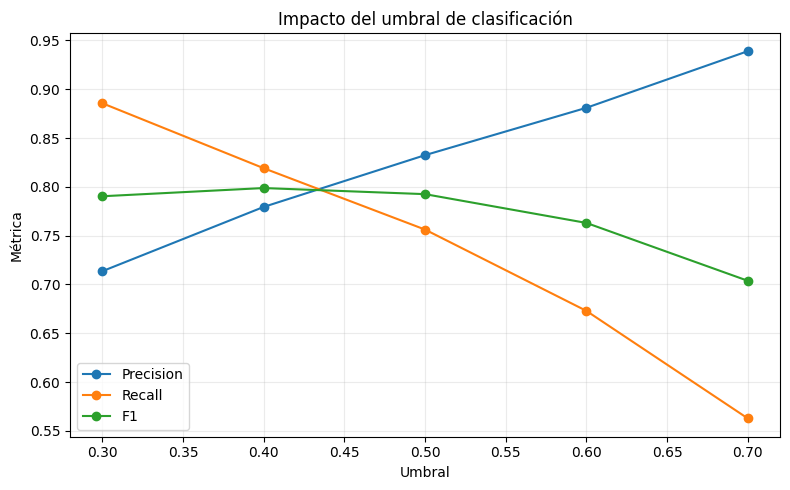

In [69]:
# Visualizamos el trade-off entre Precision, Recall y F1.
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["F1"],
    marker="o",
    label="F1"
)

ax.set_title("Impacto del umbral de clasificación")
ax.set_xlabel("Umbral")
ax.set_ylabel("Métrica")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Un umbral más bajo incrementa el Recall y permite detectar más cancelaciones, aunque aumenta los falsos positivos. Como el objetivo de negocio busca anticipar reservas riesgosas, se adopta **0,40** como umbral operativo de referencia: ofrece un mayor Recall sin reducir excesivamente Precision. El ROC-AUC, al no depender del umbral, continúa siendo la métrica principal de comparación.

## 13. Evaluación final sobre el conjunto de prueba

Una vez seleccionado y optimizado el modelo, se utiliza por primera vez el conjunto de prueba. Esta evaluación proporciona una estimación más honesta del rendimiento esperado sobre reservas no utilizadas durante el entrenamiento o la selección de hiperparámetros.

In [85]:
probabilidades_test = mejor_modelo.predict_proba(X_test)[:, 1]

# Umbral operativo seleccionado a partir de las predicciones out-of-fold.
umbral_final = 0.40
predicciones_test = (
    probabilidades_test >= umbral_final
).astype(int)

metricas_finales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1"
    ],
    "Valor": [
        accuracy_score(y_test, predicciones_test),
        roc_auc_score(y_test, probabilidades_test),
        average_precision_score(y_test, probabilidades_test),
        precision_score(y_test, predicciones_test, zero_division=0),
        recall_score(y_test, predicciones_test, zero_division=0),
        f1_score(y_test, predicciones_test, zero_division=0)
    ]
})

metricas_finales.round(4)

,Métrica,Valor
0,Accuracy,0.8497
1,ROC-AUC,0.9295
2,PR-AUC,0.8944
3,Precision,0.7793
4,Recall,0.8076
5,F1,0.7932


In [71]:
# Informe completo por clase.
print(
    classification_report(
        y_test,
        predicciones_test,
        target_names=[
            "No cancelada",
            "Cancelada"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

No cancelada     0.8910    0.8731    0.8820     15096
   Cancelada     0.7793    0.8076    0.7932      8378

    accuracy                         0.8497     23474
   macro avg     0.8352    0.8403    0.8376     23474
weighted avg     0.8512    0.8497    0.8503     23474



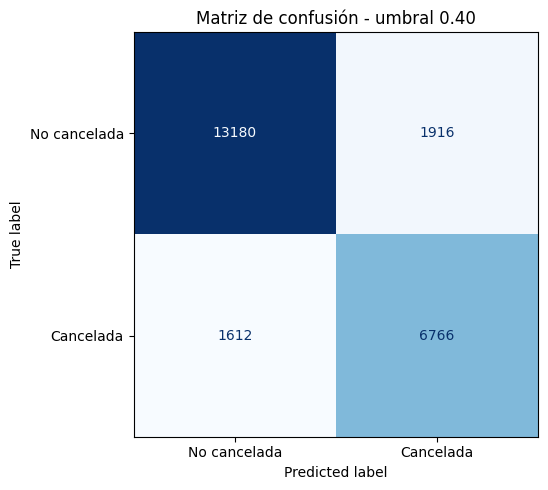

In [86]:
# Matriz de confusión.
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test,
    display_labels=[
        "No cancelada",
        "Cancelada"
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title(
    f"Matriz de confusión - umbral {umbral_final:.2f}"
)

plt.tight_layout()
plt.show()

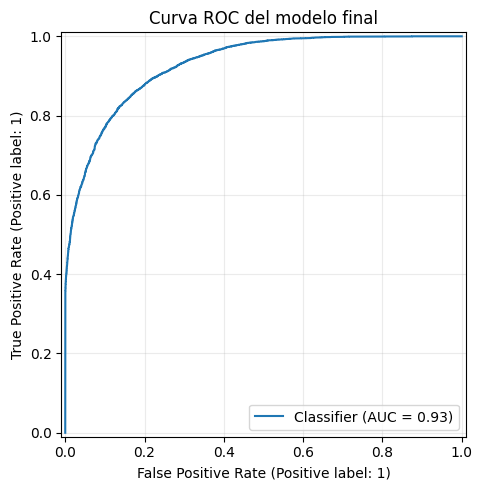

In [73]:
# Curvas ROC y Precision-Recall.
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    probabilidades_test,
    ax=ax
)

ax.set_title("Curva ROC del modelo final")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

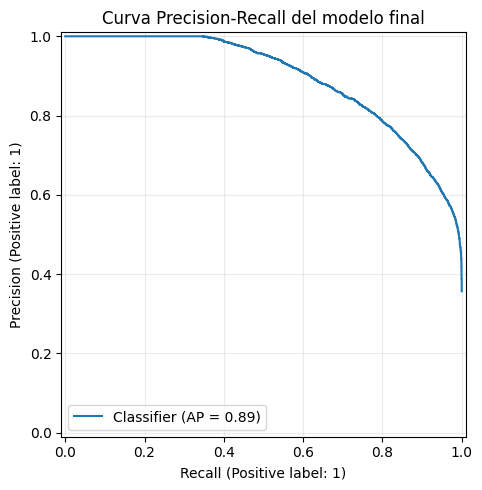

In [74]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilidades_test,
    ax=ax
)

ax.set_title("Curva Precision-Recall del modelo final")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

La evaluación final debe interpretarse en conjunto: ROC-AUC mide la capacidad global de discriminación, PR-AUC resulta especialmente útil para la clase positiva y el umbral 0,40 prioriza detectar una mayor proporción de cancelaciones. Esto implica aceptar más falsos positivos a cambio de reducir las cancelaciones que el modelo no detecta.

## 14. Explicabilidad con SHAP

SHAP permite interpretar cómo contribuye cada característica a las predicciones del modelo. Se realiza un análisis global para identificar las variables más influyentes y un análisis local para comprender una reserva específica.

In [75]:
# Accedemos a las partes internas del pipeline final.
preprocesador_final = mejor_modelo.named_steps["preprocesador"]
modelo_final = mejor_modelo.named_steps["modelo"]

# Tomamos una muestra del conjunto de prueba para que el análisis SHAP
# sea más rápido y mantenga una cantidad suficiente de observaciones.
tamano_muestra_shap = min(1000, len(X_test))

X_shap = X_test.sample(
    n=tamano_muestra_shap,
    random_state=42
)

# Aplicamos exactamente el mismo preprocesamiento utilizado por el modelo.
X_shap_transformado = preprocesador_final.transform(X_shap)

# Recuperamos los nombres de las variables después del One-Hot Encoding.
nombres_features = preprocesador_final.get_feature_names_out()

# Creamos el explicador para el modelo de árboles.
explainer = shap.TreeExplainer(modelo_final)

# Calculamos los valores SHAP.
shap_values = explainer.shap_values(X_shap_transformado)

print(f"Observaciones explicadas con SHAP: {len(X_shap):,}")
print(f"Características después del preprocesamiento: {len(nombres_features)}")

Observaciones explicadas con SHAP: 1,000
Características después del preprocesamiento: 133


### 14.1 Importancia global de las características

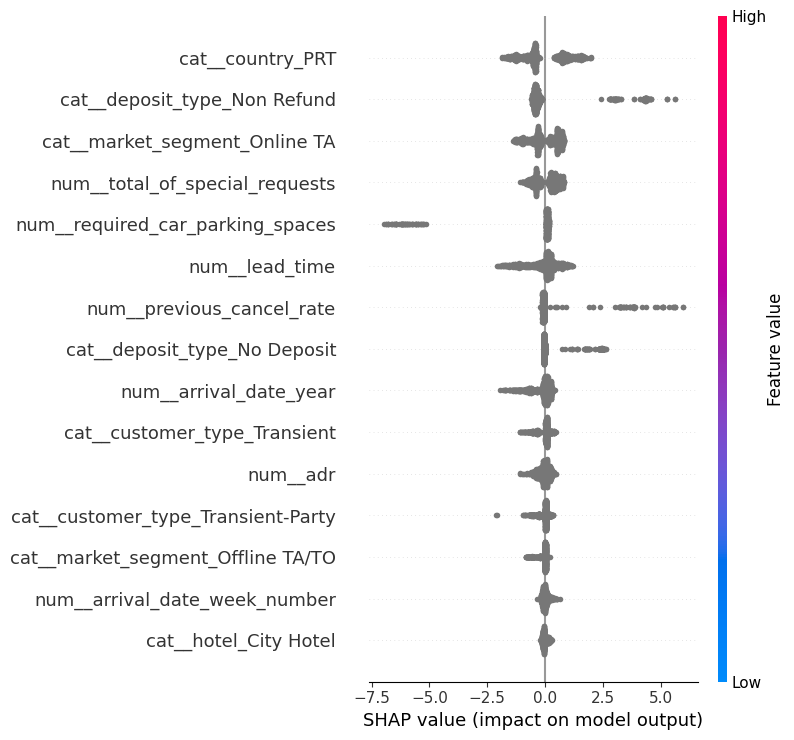

In [76]:
# Gráfico resumen global.
shap.summary_plot(
    shap_values,
    X_shap_transformado,
    feature_names=nombres_features,
    max_display=15,
    show=True
)

In [87]:
# Calculamos la importancia media absoluta de SHAP para resumirla en tabla.
importancia_shap = pd.DataFrame({
    "variable": nombres_features,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

importancia_shap["variable"] = (
    importancia_shap["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_shap = (
    importancia_shap
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

top_shap

,variable,mean_abs_shap
86,country_PRT,0.857173
121,deposit_type_Non Refund,0.813693
104,market_segment_Online TA,0.526229
14,total_of_special_requests,0.456064
13,required_car_parking_spaces,0.454436
0,lead_time,0.414439
22,previous_cancel_rate,0.319459
120,deposit_type_No Deposit,0.302829
1,arrival_date_year,0.253365
125,customer_type_Transient,0.189336


### 14.2 Explicación local de una reserva

Además del análisis global, se selecciona una reserva del conjunto de prueba y se observa qué variables empujaron su predicción hacia mayor o menor riesgo de cancelación.

Probabilidad predicha de cancelación: 32.43%


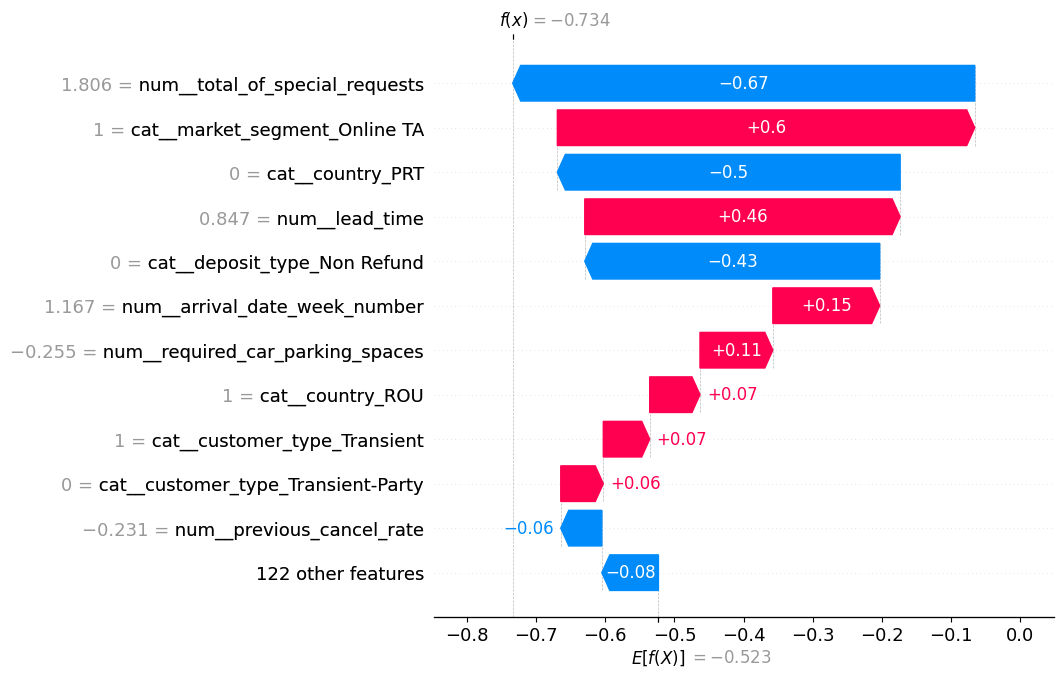

In [78]:
# Seleccionamos una observación de la muestra SHAP.
indice_local = 0

# Probabilidad predicha para esa reserva.
probabilidad_local = mejor_modelo.predict_proba(
    X_shap.iloc[[indice_local]]
)[:, 1][0]

print(
    f"Probabilidad predicha de cancelación: "
    f"{probabilidad_local:.2%}"
)

# Convertimos la observación transformada a un vector denso
# únicamente para construir la explicación local.
fila_transformada = X_shap_transformado[indice_local]

if hasattr(fila_transformada, "toarray"):
    fila_transformada = fila_transformada.toarray().ravel()
else:
    fila_transformada = np.asarray(
        fila_transformada
    ).ravel()

explicacion_local = shap.Explanation(
    values=shap_values[indice_local],
    base_values=explainer.expected_value,
    data=fila_transformada,
    feature_names=nombres_features
)

shap.plots.waterfall(
    explicacion_local,
    max_display=12
)

Los valores SHAP positivos empujan la predicción hacia una mayor probabilidad de cancelación, mientras que los valores negativos la reducen. Esto permite justificar tanto el comportamiento general del modelo como decisiones individuales.

## 15. Interpretación de negocio y conclusiones

El objetivo final no es únicamente obtener una métrica alta, sino traducir los resultados del modelo en información útil para la gestión hotelera.

In [79]:
# Mostramos las principales variables según SHAP para apoyar
# las conclusiones de negocio con evidencia del modelo.
top_shap.head(10)

,variable,mean_abs_shap
86,country_PRT,0.857173
121,deposit_type_Non Refund,0.813693
104,market_segment_Online TA,0.526229
14,total_of_special_requests,0.456064
13,required_car_parking_spaces,0.454436
0,lead_time,0.414439
22,previous_cancel_rate,0.319459
120,deposit_type_No Deposit,0.302829
1,arrival_date_year,0.253365
125,customer_type_Transient,0.189336


### Principales conclusiones

El análisis exploratorio y el modelo muestran que el riesgo de cancelación no depende de una sola variable. Factores relacionados con la anticipación de la reserva, las condiciones comerciales, el historial del cliente y algunas características operativas contribuyen conjuntamente a la predicción.

Entre los patrones observados se destacan:

- las reservas realizadas con mayor anticipación presentan mayor riesgo de cancelación;
- determinados tipos de depósito y segmentos de mercado muestran comportamientos muy diferentes;
- el historial de cancelaciones previas aporta información relevante;
- las solicitudes especiales y los espacios de estacionamiento solicitados aparecen asociados con menor cancelación;
- el modelo puede utilizarse como un ranking de riesgo y no solamente como una clasificación rígida.

Desde el punto de vista del negocio, las probabilidades estimadas podrían utilizarse para priorizar seguimiento de reservas, diseñar políticas diferenciadas de confirmación o depósito y apoyar decisiones de ocupación y overbooking.

Estas acciones deben aplicarse con criterios comerciales y no de forma automática, ya que un modelo predictivo estima probabilidades y puede producir falsos positivos y falsos negativos.

### Limitaciones

- El dataset no contiene un identificador único de reserva, por lo que no es posible confirmar si todos los registros idénticos son duplicaciones reales.
- Algunas variables fueron excluidas por riesgo de data leakage, utilizando un criterio conservador sobre el momento de disponibilidad.
- El dataset representa un contexto hotelero específico y el rendimiento puede cambiar en otros establecimientos o períodos.
- No se dispone de una matriz real de costos de negocio, por lo que el umbral 0,40 funciona como una propuesta operativa y debería ajustarse con información económica real.

## 16. Reproducibilidad del notebook

Todo el procesamiento se concentra en un único flujo reproducible: carga, limpieza, EDA, ingeniería de atributos, separación de datos, preprocesamiento, entrenamiento, optimización, evaluación y explicabilidad.

Se utiliza `random_state=42` en las etapas aleatorias principales para facilitar la reproducción de resultados.

In [80]:
# Versiones principales utilizadas en el entorno.
versiones = pd.DataFrame({
    "Librería": [
        "Python",
        "pandas",
        "numpy",
        "scikit-learn",
        "xgboost",
        "shap"
    ],
    "Versión": [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        xgboost.__version__,
        shap.__version__
    ]
})

versiones

,Librería,Versión
0,Python,3.13.15
1,pandas,2.2.3
2,numpy,2.1.3
3,scikit-learn,1.6.1
4,xgboost,3.4.1
5,shap,0.52.0


In [81]:
# Guardado opcional del pipeline final entrenado.
# El archivo contiene tanto el preprocesamiento como el modelo.
joblib.dump(
    mejor_modelo,
    "hotel_booking_cancellation_model.joblib"
)

print(
    "Modelo guardado como "
    "hotel_booking_cancellation_model.joblib"
)

Modelo guardado como hotel_booking_cancellation_model.joblib


## 17. Documentación y estructura del repositorio

Con el objetivo de facilitar la reproducibilidad y organización del proyecto, los archivos finales se estructuran de la siguiente manera:

```text
hotel-booking-cancellation/
│
├── README.md
├── requirements.txt
│
├── notebooks/
│   └── Entrega_Final_Jose_Valbuena.ipynb
│
├── models/
│   └── hotel_booking_cancellation_model.joblib
│
└── data/
    └── README.md


## 18. Checklist final del proyecto

A continuación se verifica el cumplimiento de las principales etapas requeridas para la entrega final.

| Etapa | Estado |
|---|---|
| Formulación del problema y definición del target | ✅ |
| Definición de la métrica principal | ✅ |
| Auditoría y limpieza de datos | ✅ |
| Análisis de valores faltantes y outliers | ✅ |
| Prevención de Data Leakage | ✅ |
| Análisis Exploratorio de Datos (EDA) | ✅ |
| Ingeniería de atributos | ✅ |
| Encoding y preprocesamiento mediante Pipeline | ✅ |
| Separación Train/Test | ✅ |
| Modelo baseline | ✅ |
| Comparación de múltiples modelos | ✅ |
| Validación cruzada | ✅ |
| Optimización de hiperparámetros | ✅ |
| Selección del modelo final | ✅ |
| Evaluación sobre conjunto de prueba | ✅ |
| Análisis de Precision, Recall, F1 y ROC-AUC | ✅ |
| Selección del umbral de clasificación | ✅ |
| Interpretabilidad mediante SHAP | ✅ |
| Interpretación de resultados desde el negocio | ✅ |
| Notebook reproducible | ✅ |
| README del proyecto | ✅ |
| Archivo requirements.txt | ✅ |
| Modelo final exportado | ✅ |
| Dataset documentado con fuente de acceso | ✅ |

## Cierre

El proyecto integra un pipeline completo de Data Science, desde la comprensión y preparación de los datos hasta la selección, optimización e interpretación del modelo final.

El modelo XGBoost seleccionado alcanzó un ROC-AUC de aproximadamente 0,93 sobre el conjunto de prueba, mostrando una buena capacidad para discriminar entre reservas con distinto riesgo de cancelación.

Además del rendimiento predictivo, se priorizó la reproducibilidad del proceso, la prevención de Data Leakage y la interpretabilidad de las predicciones mediante SHAP.